<a href="https://colab.research.google.com/github/IJackson00/Week2Assignment2LogReg/blob/main/ClusteringModel1--.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

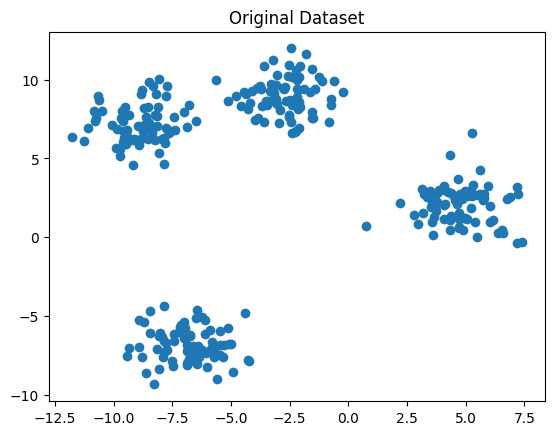

In [ ]:
# Create dataset
X, y = make_blobs(n_samples=300, centers=4, cluster_std=1.2, random_state=42)

# Visualize raw data
plt.scatter(X[:, 0], X[:, 1])
plt.title("Original Dataset")
plt.show()

K-Means Silhouette Score: 0.7518318432861294


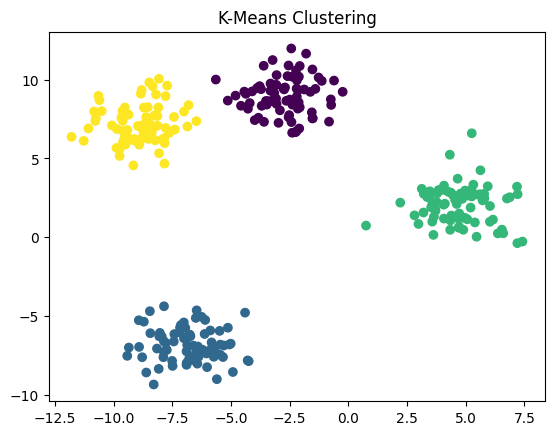

In [ ]:
# Apply K-Means
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

# Silhouette Score
kmeans_score = silhouette_score(X, kmeans_labels)
print("K-Means Silhouette Score:", kmeans_score)

# Plot clusters
plt.scatter(X[:, 0], X[:, 1], c=kmeans_labels)
plt.title("K-Means Clustering")
plt.show()

DBSCAN Silhouette Score: 0.7227139360433864


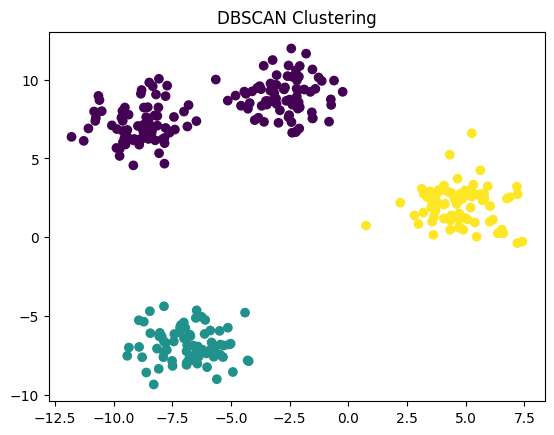

In [ ]:
# Scale data (important for DBSCAN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Silhouette Score (only if more than 1 cluster exists)
if len(set(dbscan_labels)) > 1:
    dbscan_score = silhouette_score(X_scaled, dbscan_labels)
    print("DBSCAN Silhouette Score:", dbscan_score)
else:
    print("DBSCAN could not form meaningful clusters")

# Plot clusters
plt.scatter(X[:, 0], X[:, 1], c=dbscan_labels)
plt.title("DBSCAN Clustering")
plt.show()

In [ ]:
import pandas as pd

df = pd.read_csv('/content/ClusteringModel1.csv')
display(df.head())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,12/6/2016,16-06-2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,11/10/2015,18-10-2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,11/10/2015,18-10-2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
#Create a Pivot table of CustomerID,using Sub-Categories
df.pivot_table(index='Customer ID', columns='Sub-Category', values='Sales', aggfunc='sum')

Sub-Category,Accessories,Appliances,Art,Binders,Bookcases,Chairs,Copiers,Envelopes,Fasteners,Furnishings,Labels,Machines,Paper,Phones,Storage,Supplies,Tables
Customer ID,,,,,,,,,,,,,,,,,
AA-10315,41.720,415.920,NaN,685.108,NaN,NaN,NaN,NaN,2.304,14.560,NaN,NaN,14.940,431.976,26.960,3930.072,NaN
AA-10375,649.950,NaN,5.248,74.004,NaN,NaN,NaN,NaN,NaN,28.400,NaN,NaN,80.080,116.980,101.728,NaN,NaN
AA-10480,479.970,NaN,8.640,NaN,NaN,NaN,NaN,NaN,NaN,27.460,NaN,NaN,108.522,209.970,508.110,NaN,447.840
AA-10645,NaN,NaN,5.280,113.940,1279.165,2347.888,NaN,43.960,NaN,123.660,NaN,NaN,119.280,354.682,699.080,NaN,NaN
AB-10015,NaN,NaN,17.940,NaN,341.960,48.712,NaN,NaN,NaN,NaN,NaN,NaN,NaN,221.980,255.564,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
XP-21865,245.154,291.036,142.110,101.630,NaN,NaN,NaN,15.520,15.260,811.298,NaN,NaN,672.090,NaN,80.560,NaN,NaN
YC-21895,NaN,NaN,57.750,NaN,NaN,NaN,1199.976,NaN,NaN,124.410,NaN,NaN,57.620,329.584,3685.010,NaN,NaN
YS-21880,236.000,NaN,9.552,2828.028,NaN,436.704,NaN,98.460,NaN,65.940,NaN,NaN,NaN,NaN,2687.180,NaN,358.580


In [ ]:
#Calculate a Pivot table of CustomerID,using Sub-Categories
pivot = df.pivot_table(index='Customer ID', columns='Sub-Category', values='Sales', aggfunc='sum', margins=True, margins_name='Total')
pivot=pivot.fillna(0)

pivot=pivot.apply(lambda x: x/x['Total'])
#pivot
pivot_pct=pivot.div(pivot['Total'], axis=0)
pivot=pivot.drop(columns=['Total'], axis=1)
pivot=pivot.round(2)
pivot_pct

Sub-Category,Accessories,Appliances,Art,Binders,Bookcases,Chairs,Copiers,Envelopes,Fasteners,Furnishings,Labels,Machines,Paper,Phones,Storage,Supplies,Tables,Total
Customer ID,,,,,,,,,,,,,,,,,,
AA-10315,0.102917,1.597047,0.000000,1.390680,0.000000,0.000000,0.000000,0.000000,0.314562,0.065556,0.0,0.0,0.078604,0.540484,0.049730,34.767701,0.000000,1.0
AA-10375,8.444039,0.000000,0.420822,0.791137,0.000000,0.000000,0.000000,0.000000,0.000000,0.673441,0.0,0.0,2.218933,0.770838,0.988258,0.000000,0.000000,1.0
AA-10480,3.679014,0.000000,0.408757,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.384174,0.0,0.0,1.774128,0.816311,2.912291,0.000000,2.776173,1.0
AA-10645,0.000000,0.000000,0.087924,0.252954,5.028343,3.228138,0.000000,1.204864,0.000000,0.608945,0.0,0.0,0.686366,0.485354,1.410344,0.000000,0.000000,1.0
AB-10015,0.000000,0.000000,1.714908,0.000000,7.716488,0.384465,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,1.743731,2.959673,0.000000,0.000000,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YC-21895,0.000000,0.000000,0.896887,0.000000,0.000000,0.000000,3.379916,0.000000,0.000000,0.571370,0.0,0.0,0.309225,0.420629,6.933459,0.000000,0.000000,1.0
YS-21880,0.481957,0.000000,0.120400,4.752330,0.000000,0.454486,0.000000,2.042671,0.000000,0.245785,0.0,0.0,0.000000,0.000000,4.103487,0.000000,0.592228,1.0
ZC-21910,1.466595,0.576623,0.645102,1.563706,0.000000,1.516552,0.000000,0.483223,0.427034,0.468386,0.0,0.0,0.646578,1.256563,0.282625,0.000000,2.778946,1.0


In [ ]:
#Scale the data
scaler=StandardScaler()
scaledData=scaler.fit_transform(pivot_pct)
scaledData

In [24]:
#Apply the Kmeans Clustering
kmeans=KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(scaler.fit_transform(pivot_pct))


In [ ]:
pivot_pct

Sub-Category,Accessories,Appliances,Art,Binders,Bookcases,Chairs,Copiers,Envelopes,Fasteners,Furnishings,Labels,Machines,Paper,Phones,Storage,Supplies,Tables,Total
Customer ID,,,,,,,,,,,,,,,,,,
AA-10315,0.102917,1.597047,0.000000,1.390680,0.000000,0.000000,0.000000,0.000000,0.314562,0.065556,0.0,0.0,0.078604,0.540484,0.049730,34.767701,0.000000,1.0
AA-10375,8.444039,0.000000,0.420822,0.791137,0.000000,0.000000,0.000000,0.000000,0.000000,0.673441,0.0,0.0,2.218933,0.770838,0.988258,0.000000,0.000000,1.0
AA-10480,3.679014,0.000000,0.408757,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.384174,0.0,0.0,1.774128,0.816311,2.912291,0.000000,2.776173,1.0
AA-10645,0.000000,0.000000,0.087924,0.252954,5.028343,3.228138,0.000000,1.204864,0.000000,0.608945,0.0,0.0,0.686366,0.485354,1.410344,0.000000,0.000000,1.0
AB-10015,0.000000,0.000000,1.714908,0.000000,7.716488,0.384465,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,1.743731,2.959673,0.000000,0.000000,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YC-21895,0.000000,0.000000,0.896887,0.000000,0.000000,0.000000,3.379916,0.000000,0.000000,0.571370,0.0,0.0,0.309225,0.420629,6.933459,0.000000,0.000000,1.0
YS-21880,0.481957,0.000000,0.120400,4.752330,0.000000,0.454486,0.000000,2.042671,0.000000,0.245785,0.0,0.0,0.000000,0.000000,4.103487,0.000000,0.592228,1.0
ZC-21910,1.466595,0.576623,0.645102,1.563706,0.000000,1.516552,0.000000,0.483223,0.427034,0.468386,0.0,0.0,0.646578,1.256563,0.282625,0.000000,2.778946,1.0


In [ ]:
pivot_pct=pivot.drop(columns=['Total'], axis=1)
pivot_pct=pivot_pct.round(2)
pivot_pct

Sub-Category,Accessories,Appliances,Art,Binders,Bookcases,Chairs,Copiers,Envelopes,Fasteners,Furnishings,Labels,Machines,Paper,Phones,Storage,Supplies,Tables
Customer ID,,,,,,,,,,,,,,,,,
AA-10315,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.08,0.00
AA-10375,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00
AA-10480,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00
AA-10645,0.00,0.0,0.0,0.00,0.01,0.01,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00
AB-10015,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YC-21895,0.00,0.0,0.0,0.00,0.00,0.00,0.01,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.02,0.00,0.00
YS-21880,0.00,0.0,0.0,0.01,0.00,0.00,0.00,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.01,0.00,0.00
ZC-21910,0.01,0.0,0.0,0.01,0.00,0.01,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.01
